# Predictive Mining 1 - how solid are the behavioural groups?

Week five split the 143 profiled owners into three behavioural groups by the way they use
email: a broadcaster/exec group of 8 that held Lay, Skilling and a Whalley desk, an
outward-facing group of 50, and an internal majority of 85. Before the prediction work leans
on those groups it is worth pushing on them, and this notebook does it in two steps.

The first is an attribution fix. Two of the mailboxes in that broadcaster group are not really
the executives at all: `lay-k` sends 94% from Rosalee Fleming and `skilling-j` 79% from Sherri
Sera, their executive assistants, and the "Whalley desk" is Greg Whalley's assistant Liz Taylor
(owner `whalley-l`). The week-five clustering folded the assistants' mail into the executives,
so it was partly clustering offices rather than people. Here we remove those delegate sends
(listed in `eda-5/refs/assistant_delegates.csv`) and re-cluster on genuine authorship. Week
five itself is left as it stands; this is the corrected re-run.

The second is a stress test of the result: can we actually say who belongs in the broadcaster
group, and which features do the work of separating the groups at all. Everything runs on the
cleaned tables under `eda-5/clean/`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_samples
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, fcluster

import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from PIL import Image as _PILImage
from IPython.display import Image as _PNG, display as _show

def find_root() -> Path:
    here = Path.cwd()
    for base in (here, *here.parents):
        if (base / "eda-5" / "clean" / "messages_clean.parquet").exists():
            return base
    raise FileNotFoundError("eda-5/clean not found above " + str(here))

ROOT = find_root()
CLEAN = ROOT / "eda-5" / "clean"
REFS = ROOT / "eda-5" / "refs"
PLOTS = ROOT / "pred-1" / "plots"
PLOTS.mkdir(parents=True, exist_ok=True)

BLUE, RED, ORANGE, GREEN, GREY = "#3b6fb6", "#d04545", "#e08a3c", "#3a7d44", "#b8b8b8"
PURPLE = "#6a3d9a"
pio.templates["enron"] = go.layout.Template(layout=dict(
    font=dict(family="DejaVu Sans, Arial, sans-serif", size=16, color="#222222"),
    title=dict(font=dict(size=23), x=0.5, xanchor="center"),
    paper_bgcolor="white", plot_bgcolor="white",
    xaxis=dict(showgrid=True, gridcolor="#ececec", zeroline=False, linecolor="#bbbbbb",
               ticks="outside", title_font=dict(size=16), tickfont=dict(size=14), automargin=True),
    yaxis=dict(showgrid=True, gridcolor="#ececec", zeroline=False, linecolor="#bbbbbb",
               ticks="outside", title_font=dict(size=16), tickfont=dict(size=14), automargin=True)))
pio.templates.default = "enron"

def save_fig(fig, name, w=1100, h=560, margin=None):
    fig.update_layout(width=w, height=h, margin=margin or dict(l=90, r=70, t=80, b=80))
    out = PLOTS / name
    fig.write_image(out, scale=3)
    _PILImage.open(out).save(out, dpi=(300, 300))
    _show(_PNG(filename=str(out)))
    return fig

# label a mailbox by the real person, so an assistant-run desk shows the assistant
ROLE_NAME = {}
def disp(handle):
    nm = ROLE_NAME.get(handle)
    if nm:
        return f"{nm[0]} {nm[1][:1].upper()}".strip()
    sn, _, ini = handle.partition("-")
    return f"{sn.replace('.', ' ').title()} {ini.upper()}".strip()

In [2]:
msg = pd.read_parquet(CLEAN / "messages_clean.parquet")
rcp = pd.read_parquet(CLEAN / "recipients_clean.parquet")
roles = pd.read_parquet(CLEAN / "people_roles.parquet").set_index("owner")
ROLE_NAME.update({o: (str(roles.loc[o, "last_name"]), str(roles.loc[o, "first_name"]))
                  for o in roles.index})

# Drop delegate sends: an assistant's own address folded into an executive's mailbox.
DELEGATE = set(pd.read_csv(REFS / "assistant_delegates.csv", sep=";")["assistant_addr"])
all_authored = msg[msg["sender_person"].notna()]
authored = all_authored[~all_authored["from_addr_norm"].isin(DELEGATE)].copy()

MIN_AUTHORED = 30
ac = authored.groupby("sender_person").size()
keep = sorted(ac[ac >= MIN_AUTHORED].index)

a = authored[authored["date_plausible"] & authored["date"].notna()].copy()
a["wknd"] = a["date"].dt.dayofweek >= 5
g = authored.groupby("sender_person"); ag = a.groupby("sender_person")

F = pd.DataFrame(index=keep)
F["n_sent"]        = g.size()
F["med_len"]       = g["body_chars"].median()
F["mean_recip"]    = g["recipient_count"].mean()
F["ext_ratio"]     = g["has_external_recipient"].mean()
F["cc_ratio"]      = g["cc_count"].sum() / g["recipient_count"].sum().replace(0, np.nan)
F["broadcast"]     = authored.assign(b=authored["recipient_count"] > 5).groupby("sender_person")["b"].mean()
F["root_ratio"]    = g["is_thread_root"].mean()
F["wknd_ratio"]    = ag["wknd"].mean()
F["active_months"] = (ag["date"].max() - ag["date"].min()).dt.days / 30.44
F["del_rate"]      = msg.assign(d=msg["folder_group"].eq("deleted")).groupby("mailbox_owner")["d"].mean().reindex(keep)
ei = rcp.merge(msg[["message_id", "sender_person"]], on="message_id")
ei = ei[(ei["channel"] == "to") & ei["is_internal_recipient"] & ~ei["recipient_is_list"]
        & ~ei["is_self"] & ei["sender_person"].notna() & ei["recipient_person"].notna()
        & (ei["sender_person"] != ei["recipient_person"])]
F["out_deg"] = ei.groupby("sender_person")["recipient_person"].nunique().reindex(keep)
F["in_deg"]  = ei.groupby("recipient_person")["sender_person"].nunique().reindex(keep)
F = F.reindex(keep).fillna(F.median())

Fraw = F.copy()
LOGCOLS = ["n_sent", "med_len", "mean_recip", "active_months", "out_deg", "in_deg"]
for c in LOGCOLS:
    F[c] = np.log1p(F[c])
FEATS = list(F.columns)
PRETTY = {"n_sent": "messages sent", "med_len": "median body length",
    "mean_recip": "recipients per message", "ext_ratio": "share external",
    "cc_ratio": "Cc share", "broadcast": "share to >5 people",
    "root_ratio": "thread-opening share", "wknd_ratio": "weekend share",
    "active_months": "active months", "del_rate": "mailbox deletion rate",
    "out_deg": "people written to", "in_deg": "people writing in"}

X = StandardScaler().fit_transform(F.values)
Z = linkage(X, method="ward")
clabel = fcluster(Z, 3, criterion="maxclust")
Fraw["cluster"] = clabel
prof = Fraw.groupby("cluster")[FEATS].mean()
ex  = prof["broadcast"].idxmax(); used = {ex}
out = prof.loc[~prof.index.isin(used), "ext_ratio"].idxmax(); used.add(out)
maj = [c for c in prof.index if c not in used][0]
names = {ex: "Broadcasters / execs", out: "Outward-facing", maj: "Internal majority"}
cl_name = {h: names[clabel[i]] for i, h in enumerate(keep)}
bcast = [h for h in keep if cl_name[h] == "Broadcasters / execs"]

lay_folded = int((all_authored["sender_person"] == "lay-k").sum())
lay_real   = int((authored["sender_person"] == "lay-k").sum())
print(f"delegate sends removed: {len(all_authored) - len(authored)}")
print(f"Ken Lay: {lay_folded} messages folded in -> {lay_real} genuinely his "
      f"(below the {MIN_AUTHORED} floor, so he drops out)")
print(f"profiled owners: {len(keep)}  (week five had 143)")
print({names[c]: int((clabel == c).sum()) for c in sorted(prof.index)})
print("broadcasters:", ", ".join(disp(h) for h in bcast))

delegate sends removed: 574
Ken Lay: 344 messages folded in -> 22 genuinely his (below the 30 floor, so he drops out)
profiled owners: 142  (week five had 143)
{'Outward-facing': 49, 'Broadcasters / execs': 6, 'Internal majority': 87}
broadcasters: Bailey S, Baughman D, Hain M, Panus S, Skilling J, Williams B


## What removing the assistant mail changes

The delegate fix takes 574 messages out of the authored set, all of them in two mailboxes. Ken
Lay is the casualty: 322 of the 344 messages attributed to him were written by Rosalee Fleming,
so only 22 are genuinely his, which is below the thirty-message floor, and he drops out of the
profiled set. Skilling keeps 66 of his own and stays. The roster goes from 143 to 142.

The broadcaster group tightens from eight to six. Lay is gone. Liz Taylor's desk (`whalley-l`),
which was in the group as a "Whalley", moves to the internal majority once the assistant-inflated
broadcaster cluster shrinks. The silhouette of the three-group cut even rises slightly, from 0.18
to about 0.20, because the assistant offices were some of the least typical members. What is left
is six high-volume people, and of them exactly one, Skilling, is a company executive. The result
does not overturn week five so much as sharpen it: with the offices stripped out, the broadcaster
group is much more clearly an operational role than an executive one.

## Can we tell for sure who is in the broadcaster group?

Six people fall in the corrected broadcaster group. To see how solid that is we look at the
membership three ways.

The first is the silhouette of each member, which compares how close a person sits to their own
group against the nearest other group: near one means deep inside the broadcaster group, near
zero means on the fence with the internal majority. The second is a resampling check: we redraw a
random 80% of the 142 people six hundred times, rerun the whole pipeline from scaling to the
three-group cut on each draw, and record how often each person lands back in the broadcaster
cluster. The third is a method swap, checking whether the same six stay together under k-means and
under deeper Ward cuts into four and five groups.

all 6 stay together under: ['k-means k3', 'Ward k4', 'Ward k5'] (of ['k-means k3', 'Ward k4', 'Ward k5'] )


/tmp/ipykernel_3870543/3708709217.py:43: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(out, scale=3)


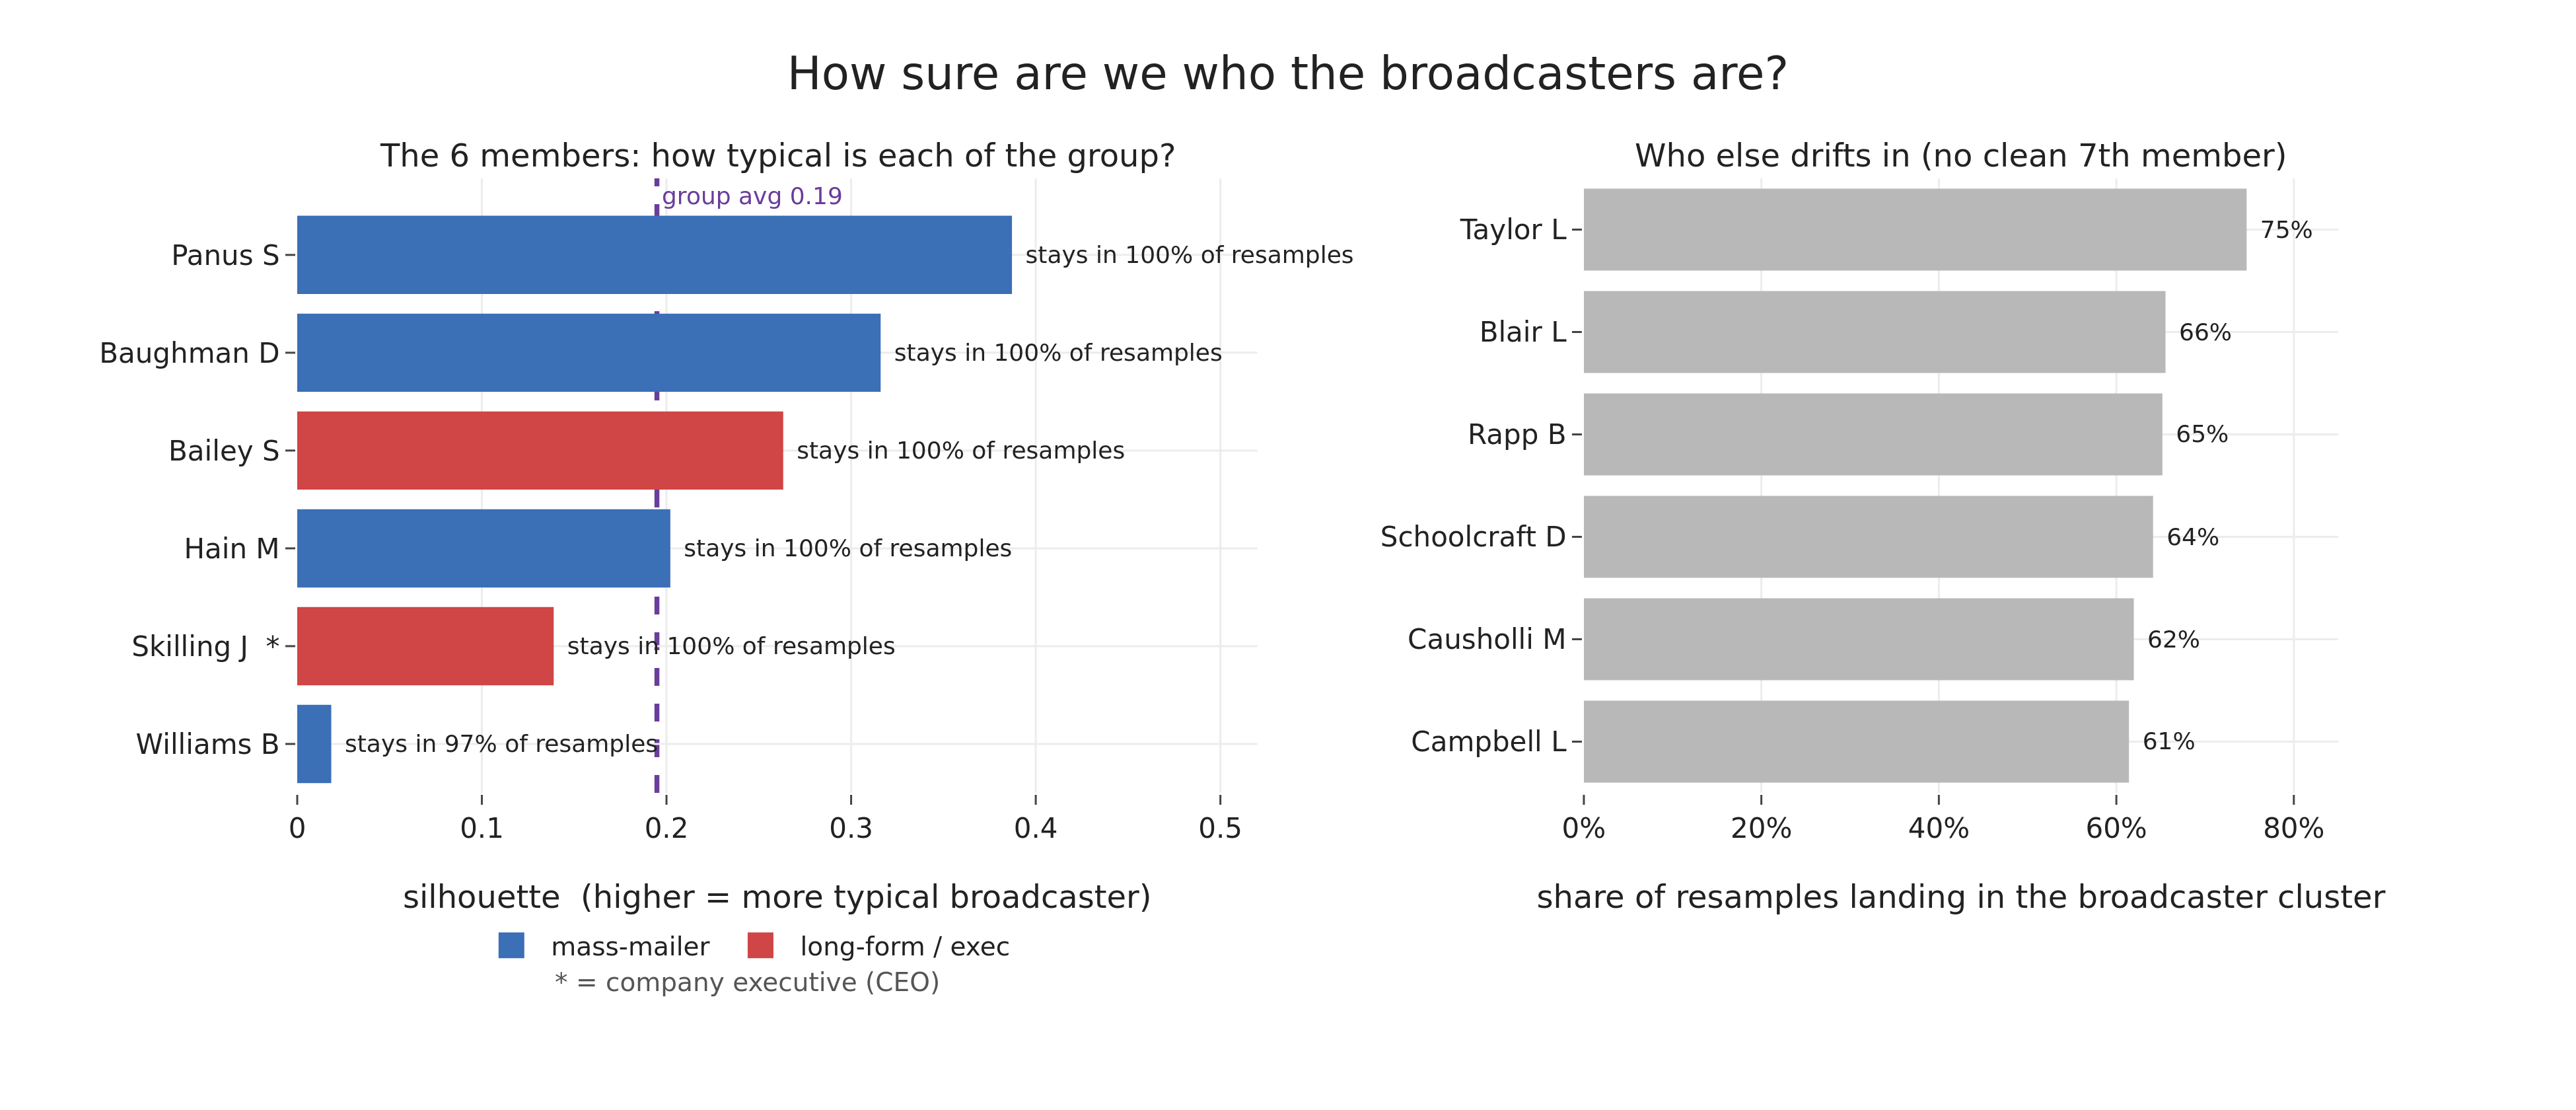

In [3]:
sil = pd.Series(silhouette_samples(X, clabel), index=keep)

rng = np.random.default_rng(0)
rawb = Fraw["broadcast"].values
n = len(keep); m = int(0.8 * n)

def broadcaster_cluster(labels, idx):
    """the resampled cluster with the highest mean raw broadcast rate"""
    sub_b = rawb[idx]
    return max(np.unique(labels), key=lambda c: sub_b[labels == c].mean())

present = np.zeros(n); inbc = np.zeros(n)
for _ in range(600):
    s = rng.choice(n, m, replace=False)
    Xs = StandardScaler().fit_transform(F.iloc[s].values)
    labs = fcluster(linkage(Xs, "ward"), 3, "maxclust")
    bc = broadcaster_cluster(labs, s)
    present[s] += 1
    inbc[s[labs == bc]] += 1
rate = pd.Series(inbc / np.maximum(present, 1), index=keep)

def bcast_set(labels):
    return set(np.array(keep)[labels == broadcaster_cluster(labels, np.arange(n))])
methods = {"k-means k3": bcast_set(KMeans(3, n_init=10, random_state=0).fit_predict(X) + 1),
           "Ward k4": bcast_set(fcluster(Z, 4, "maxclust")),
           "Ward k5": bcast_set(fcluster(Z, 5, "maxclust"))}
print("all 6 stay together under:",
      [k for k, v in methods.items() if set(bcast) <= v], "(of", list(methods), ")")

# --- figure ---
ms = sorted(bcast, key=lambda h: sil[h])
execs = {h for h in bcast if h in roles.index and bool(roles.loc[h, "is_executive"])}
flav  = {h: ("mass-mailer" if Fraw.loc[h, "broadcast"] >= 0.30 else "long-form / exec") for h in bcast}
labels = [disp(h) + ("  *" if h in execs else "") for h in ms]
cols   = [BLUE if flav[h] == "mass-mailer" else RED for h in ms]
fringe = rate[[h for h in keep if h not in bcast]].sort_values(ascending=False).head(6).sort_values()

fig = make_subplots(rows=1, cols=2, column_widths=[0.56, 0.44], horizontal_spacing=0.16,
    subplot_titles=["The 6 members: how typical is each of the group?",
                    "Who else drifts in (no clean 7th member)"])
fig.add_trace(go.Bar(y=labels, x=[sil[h] for h in ms], orientation="h", marker_color=cols,
    text=[f" stays in {rate[h]:.0%} of resamples" for h in ms], textposition="outside",
    textfont=dict(size=12), cliponaxis=False, showlegend=False), row=1, col=1)
fig.add_trace(go.Scatter(x=[None], y=[None], mode="markers",
    marker=dict(size=13, color=BLUE, symbol="square"), name="mass-mailer", showlegend=True), row=1, col=1)
fig.add_trace(go.Scatter(x=[None], y=[None], mode="markers",
    marker=dict(size=13, color=RED, symbol="square"), name="long-form / exec", showlegend=True), row=1, col=1)
fig.add_vline(x=float(sil.mean()), line=dict(color=PURPLE, dash="dash", width=2.5), layer="below", row=1, col=1)
fig.add_annotation(x=float(sil.mean()), y=5.6, text=f"group avg {sil.mean():.2f}", showarrow=False,
    font=dict(size=12, color=PURPLE), xanchor="left", row=1, col=1)
fig.update_xaxes(title_text="silhouette  (higher = more typical broadcaster)", range=[0, 0.52], row=1, col=1)
fig.add_trace(go.Bar(y=[disp(h) for h in fringe.index], x=fringe.values, orientation="h",
    marker_color=GREY, text=[f" {v:.0%}" for v in fringe.values], textposition="outside",
    textfont=dict(size=12), cliponaxis=False, showlegend=False), row=1, col=2)
fig.update_xaxes(title_text="share of resamples landing in the broadcaster cluster",
    range=[0, 0.85], tickformat=".0%", row=1, col=2)
fig.add_annotation(xref="paper", yref="paper", x=0.22, y=-0.34, showarrow=False, xanchor="center",
    text="* = company executive (CEO)", font=dict(size=13, color="#555"))
fig.update_layout(title="How sure are we who the broadcasters are?",
    legend=dict(orientation="h", x=0.22, xanchor="center", y=-0.20, yanchor="top", font=dict(size=13)))
save_fig(fig, "pc1_broadcaster_certainty.png", w=1300, h=560, margin=dict(l=150, r=120, t=90, b=160))

The six members are a fixed core. Every one returns to the broadcaster cluster in at least
97% of the resamples, and the same six stay together under k-means and when Ward is pushed to four
and five groups instead of three. On that measure, yes, we can name the broadcasters.

What the group is made of is the interesting part. It is held together by sending long mail to many
people, and it does that in two flavours. Baughman, Hain, Panus and Williams are mass-mailers, a
third or more of their messages going to more than five people at once. Bailey and Skilling reach
wide through long messages rather than raw broadcast volume. Skilling is the only company executive
left in the group, and he sits near the bottom of the silhouette at 0.14, held in by message length
rather than by broadcasting. The other five are a commercial manager, a regulatory counsel, two
legal specialists and a trading-desk manager. The broadcaster role, once the assistant offices are
removed, is operational, not executive.

The boundary is soft, and the softest point is telling. The non-member most often pulled into the
broadcaster cluster is Liz Taylor's desk (`whalley-l`), in three resamples out of four: the
executive office that the attribution fix took out sits right on the edge of the group it used to
anchor. There is no clean seventh member behind it, only a rotating fringe of people such as Rapp,
Schoolcraft and Campbell who are in on one draw and out on the next.

## The profile heatmap, and the features that look the same

Week five summarised the groups with a profile heatmap: each group's mean of every feature, in
standard deviations from the mean of the three groups. Reproduced here on the corrected clustering,
it has the same look. Almost every cell sits near one standard deviation, so at a glance every
feature seems to define the groups about equally, and the only cells that fall below 0.1, where a
group lands right at the three-group midpoint, are the two boxed in green.

cells within 0.1 of the 3-group mean (group sits at the midpoint):
  Broadcasters / execs active months          z=+0.029  population z=-0.08
  Internal majority    thread-opening share   z=-0.064  population z=-0.10


/tmp/ipykernel_3870543/3708709217.py:43: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(out, scale=3)


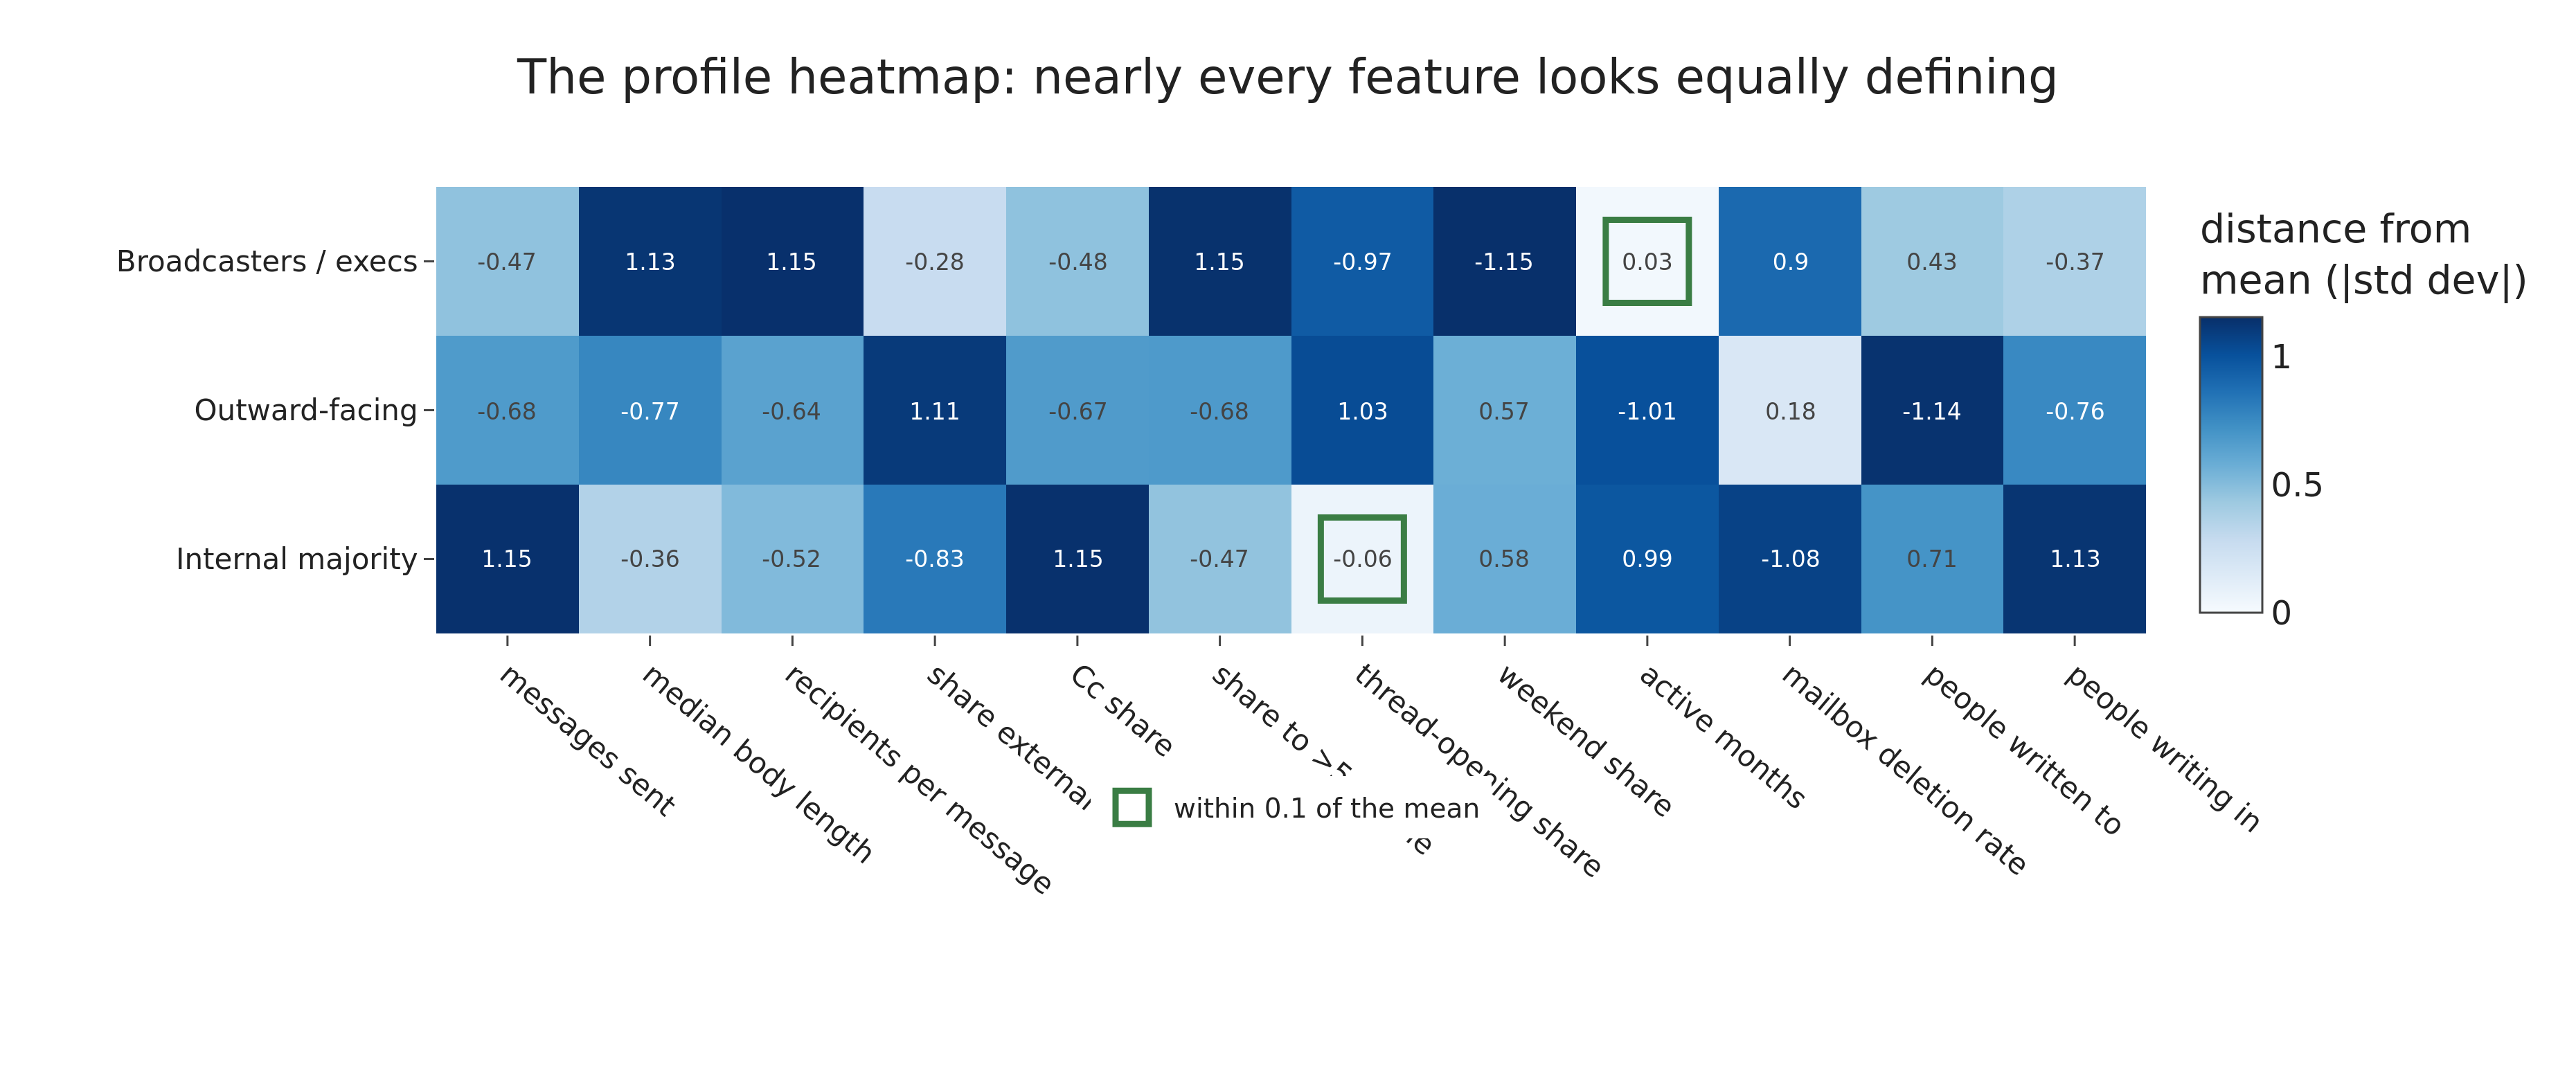

In [4]:
ORDER = ["Broadcasters / execs", "Outward-facing", "Internal majority"]
profn = prof.rename(index=names).loc[ORDER]
zprof = (profn - profn.mean()) / profn.std()           # standardise over the 3 group means (p5 style)
zpop  = (profn - Fraw[FEATS].mean()) / Fraw[FEATS].std()
near  = [(grp, f) for grp in ORDER for f in FEATS if abs(zprof.loc[grp, f]) < 0.10]
print("cells within 0.1 of the 3-group mean (group sits at the midpoint):")
for grp, f in near:
    print(f"  {grp:20s} {PRETTY[f]:22s} z={zprof.loc[grp, f]:+.3f}  population z={zpop.loc[grp, f]:+.2f}")

absz = zprof.abs()
cols_p = [PRETTY[c] for c in FEATS]
fig = go.Figure(go.Heatmap(
    z=absz.values, x=cols_p, y=ORDER, colorscale="Blues", zmin=0, zmax=float(absz.values.max()),
    colorbar=dict(title="distance from<br>mean (|std dev|)"),
    text=np.round(zprof.values, 2), texttemplate="%{text}", textfont=dict(size=11)))
fig.add_trace(go.Scatter(x=[PRETTY[f] for _, f in near], y=[grp for grp, _ in near], mode="markers",
    marker=dict(symbol="square-open", size=40, color=GREEN, line=dict(width=3)),
    name="within 0.1 of the mean", showlegend=True))
fig.update_xaxes(tickangle=40)
fig.update_yaxes(autorange="reversed")   # broadcasters on top, internal majority at the bottom
fig.update_layout(title="The profile heatmap: nearly every feature looks equally defining",
    legend=dict(orientation="h", x=0.5, xanchor="center", y=-0.32, yanchor="top", font=dict(size=13)))
save_fig(fig, "pc3_cluster_profiles.png", w=1240, h=520, margin=dict(l=210, r=110, t=90, b=215))

Only two cells fall within 0.1 of the mean. The broadcasters are dead average on tenure
(active months), neither the longest- nor shortest-serving group, and the internal majority is
average on thread-opening. Those are the only spots where a group is genuinely indistinguishable
from the middle.

But reading the heatmap this way is a trap, and it is the reason for the next figure. The even
colouring is mostly an artefact of standardising only three numbers per feature: the step forces
every feature to about plus or minus one whether or not it carries signal. Weekend share is the
clearest case. It shows a striking minus 1.15 for the broadcasters, as dark as recipients per
message, which reads as one of the strongest group signatures. Yet against the whole population the
broadcasters sit at minus 0.23 on weekend share, a tiny step: the three group means are all close
together and the standardisation blows the gap up. So a faint cell here does not mark an
uninformative feature, and a dark one does not mark an informative one. To see which features
actually separate the groups we need a measure that keeps the within-group spread.

## Which features actually separate the groups?

That measure is eta-squared: of all the spread in a feature across the 142 people, the share the
three-group split accounts for. Unlike the heatmap's standardisation it keeps the within-group
scatter, so a feature near one is almost entirely explained by which group a person is in, and a
feature near zero genuinely looks the same in every group.

                        heatmap z (broadc.)  population z (broadc.)  eta_squared
weekend share                        -1.155                  -0.232        0.002
thread-opening share                 -0.967                  -0.363        0.029
mailbox deletion rate                 0.900                   0.734        0.112
share to >5 people                    1.148                   2.979        0.429
recipients per message                1.153                   3.870        0.571


/tmp/ipykernel_3870543/3708709217.py:43: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(out, scale=3)


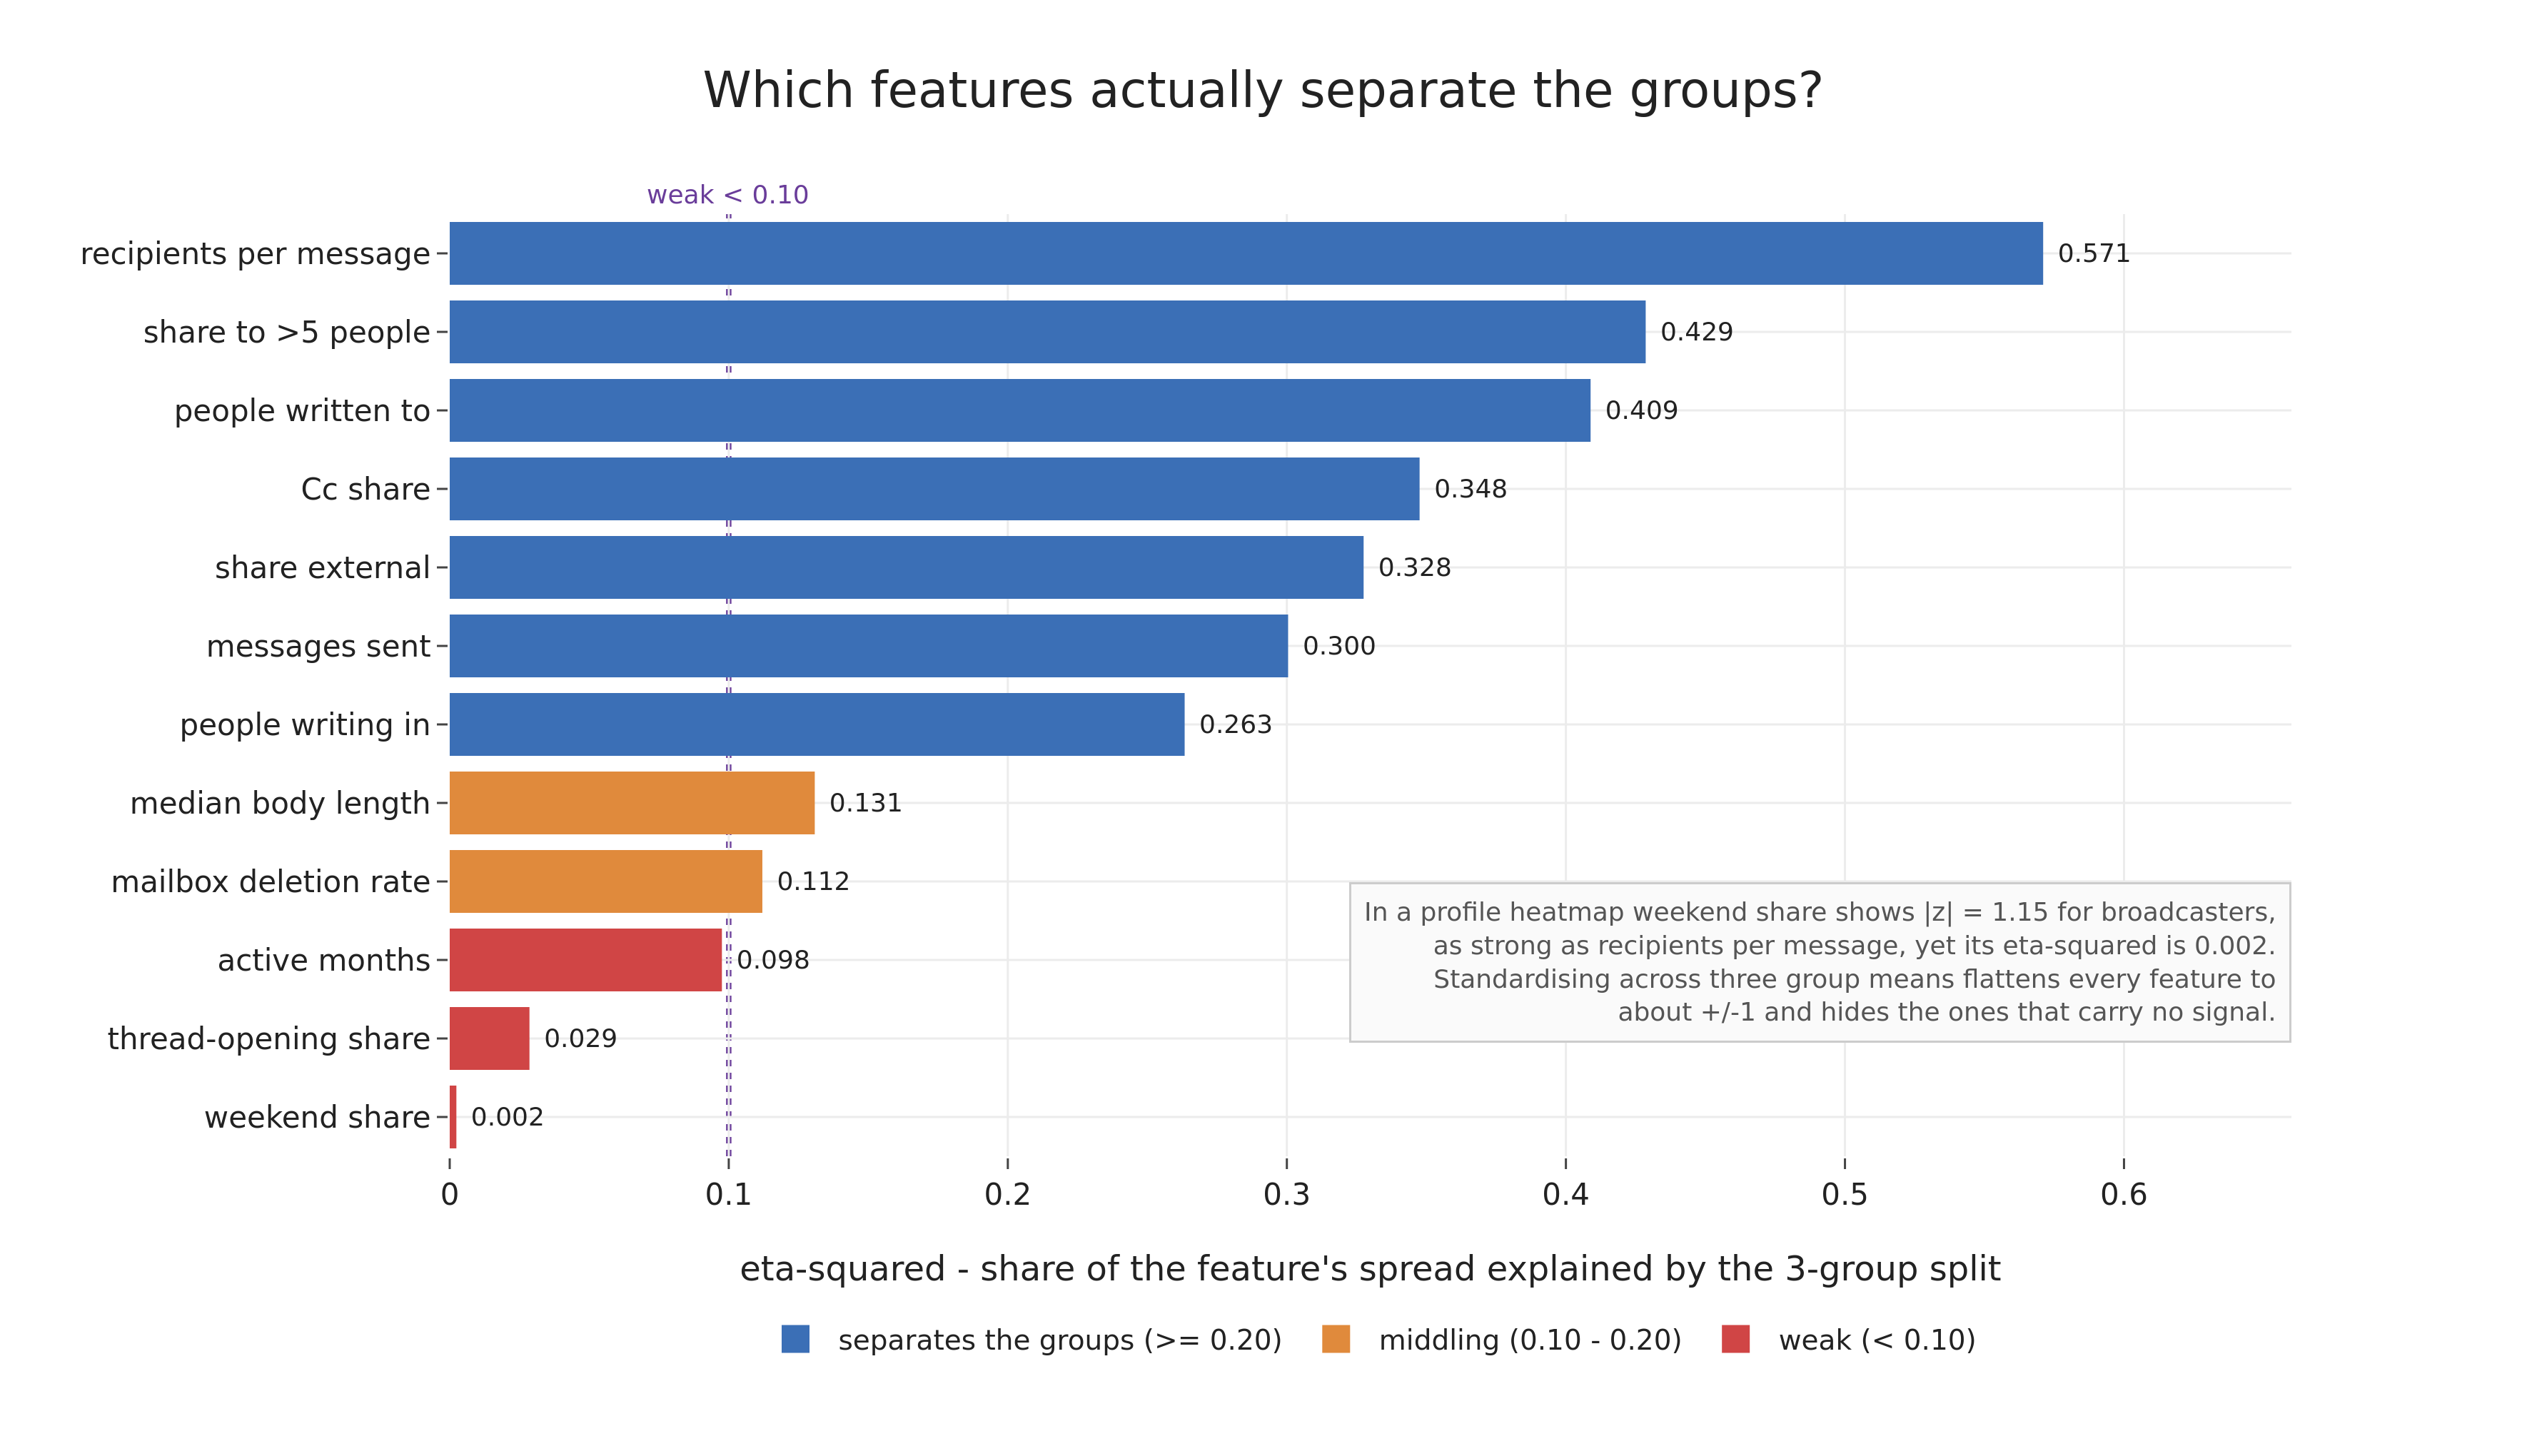

In [5]:
eta = {}
for j, f in enumerate(FEATS):
    x = X[:, j]; gm = x.mean(); sst = ((x - gm) ** 2).sum()
    ssb = sum((clabel == c).sum() * (x[clabel == c].mean() - gm) ** 2 for c in np.unique(clabel))
    eta[f] = ssb / sst
eta = pd.Series(eta).sort_values()

# crosscheck: profile-heatmap z (standardised over 3 group means) vs population z vs eta-squared
prof_named = prof.rename(index=names)
z3   = (prof_named - prof_named.mean()) / prof_named.std()
zpop = (prof_named - Fraw[FEATS].mean()) / Fraw[FEATS].std()
chk = pd.DataFrame({"heatmap z (broadc.)": z3.loc["Broadcasters / execs"],
                    "population z (broadc.)": zpop.loc["Broadcasters / execs"],
                    "eta_squared": eta}).loc[["wknd_ratio", "root_ratio", "del_rate", "broadcast", "mean_recip"]]
chk.index = [PRETTY[i] for i in chk.index]
print(chk.round(3).to_string())

fn = [PRETTY[k] for k in eta.index]; ev = eta.values
barcol = [RED if v < 0.10 else (ORANGE if v < 0.20 else BLUE) for v in ev]
fig = go.Figure(go.Bar(y=fn, x=ev, orientation="h", marker_color=barcol,
    text=[f" {v:.3f}" for v in ev], textposition="outside", textfont=dict(size=12),
    cliponaxis=False, showlegend=False))
for col, nm in [(BLUE, "separates the groups (>= 0.20)"),
                (ORANGE, "middling (0.10 - 0.20)"), (RED, "weak (< 0.10)")]:
    fig.add_trace(go.Scatter(x=[None], y=[None], mode="markers",
        marker=dict(size=13, color=col, symbol="square"), name=nm, showlegend=True))
fig.add_vline(x=0.10, line=dict(color=PURPLE, dash="dot", width=2.5), layer="below",
    annotation_text="weak &lt; 0.10", annotation_position="top",
    annotation_font=dict(size=12, color=PURPLE))
fig.update_xaxes(title_text="eta-squared - share of the feature's spread explained by the 3-group split",
    range=[0, 0.66])
fig.add_annotation(xref="paper", yref="paper", x=1.0, y=0.12, showarrow=False, xanchor="right", align="right",
    text="In a profile heatmap weekend share shows |z| = 1.15 for broadcasters,<br>"
         "as strong as recipients per message, yet its eta-squared is 0.002.<br>"
         "Standardising across three group means flattens every feature to<br>"
         "about +/-1 and hides the ones that carry no signal.",
    font=dict(size=12, color="#555"), bordercolor="#cccccc", borderwidth=1, borderpad=6, bgcolor="#fafafa")
fig.update_layout(title="Which features actually separate the groups?",
    legend=dict(orientation="h", x=0.5, xanchor="center", y=-0.16, yanchor="top", font=dict(size=13)))
save_fig(fig, "pc2_feature_separation.png", w=1180, h=680, margin=dict(l=210, r=110, t=100, b=140))

Two features carry most of the split. Recipients per message accounts for 57% of its own
spread, and the share of mail going to more than five people accounts for 43%, so the groups are
really a story about how widely people address their mail. Out-degree, external share and raw volume
fill in behind them. At the other end, three features do almost no separating work: weekend share at
0.002, thread-opening at 0.03 and active months at 0.10 look the same whatever group a person is in.

Set side by side with the heatmap, the contrast is the whole point. The three features the heatmap
lit up most evenly are among the ones with the least signal here, and the crosscheck table prints the
gap directly: weekend share reads minus 1.15 in the heatmap but only minus 0.23 against the
population, with an eta-squared of 0.002. The even colouring was the artefact, not the signal, so the
groups rest on a handful of volume and reach features rather than on the full set of twelve.

## What this says before the prediction work

Removing the assistant-authored mail sharpens week five rather than overturning it. The broadcaster
group is real and stable under resampling and method swaps, but with the delegate sends gone it is
six high-volume people, only one of whom (Skilling) is an executive, and he is the least typical
member of the group. Ken Lay's broadcasting was his assistant's and drops out entirely; Liz Taylor's
desk sits just outside the boundary. So the corrected answer is plainer than week five's: the
broadcasters are an operational communication role, not the executive suite, and the split runs on
how widely people address mail while a third of the features barely move. A label this soft at the
edge and resting on so few features is a demanding thing to predict from message text, which is the
problem the body-to-group work in `enron_eda_week6.ipynb` runs into.